# Lectura de datos y tratamiento

In [1]:
import keras
from keras import layers

In [2]:
from google.colab import files
files.upload()


Saving clinical.csv to clinical.csv
Saving protein_abundance.csv to protein_abundance.csv


{'clinical.csv': b'Sample\tHistology\tPAM50Call\tajcc_cancer_metastasis_stage_code\tajcc_neoplasm_disease_lymph_node_stage\tajcc_neoplasm_disease_stage\tajcc_tumor_stage_code\tbreast_cancer_optical_measurement_histologic_type\tbreast_carcinoma_estrogen_receptor_status\tbreast_carcinoma_progesterone_receptor_status\tbreast_carcinoma_surgical_procedure_name\tgender\ther2_immunohistochemistry_level_result\tlab_proc_her2_neu_immunohistochemistry_receptor_status\tmargin_status\tmenopause_status\tperson_neoplasm_cancer_status\tsample_type\tvital_status\nTCGA.A1.A0SB.01\t\t\tM0\tN0\tStage I\tT1c\tOther\tPositive\tNegative\tLumpectomy\tFEMALE\t\tNegative\tNegative\tPost (prior bilateral ovariectomy OR >12 mo since LMP with no prior hysterectomy)\tTUMOR FREE\tPrimary Tumor\tLIVING\nTCGA.A1.A0SD.01\tInfiltrating Ductal Carcinoma\tLumA\tM0\tN0\tStage IIA\tT2\tInfiltrating Ductal\tPositive\tPositive\tLumpectomy\tFEMALE\t\tNegative\tPositive\t\t\tPrimary Tumor\tLIVING\nTCGA.A1.A0SE.01\tMixed Histol

In [4]:
import pandas as pd
clinical = pd.read_csv('clinical.csv',sep="\t",
    escapechar="\\",
    skipinitialspace=True)
clinical.head()

,Sample,Histology,PAM50Call,ajcc_cancer_metastasis_stage_code,ajcc_neoplasm_disease_lymph_node_stage,ajcc_neoplasm_disease_stage,ajcc_tumor_stage_code,breast_cancer_optical_measurement_histologic_type,breast_carcinoma_estrogen_receptor_status,breast_carcinoma_progesterone_receptor_status,breast_carcinoma_surgical_procedure_name,gender,her2_immunohistochemistry_level_result,lab_proc_her2_neu_immunohistochemistry_receptor_status,margin_status,menopause_status,person_neoplasm_cancer_status,sample_type,vital_status
0,TCGA.A1.A0SB.01,NaN,NaN,M0,N0,Stage I,T1c,Other,Positive,Negative,Lumpectomy,FEMALE,NaN,Negative,Negative,Post (prior bilateral ovariectomy OR >12 mo si...,TUMOR FREE,Primary Tumor,LIVING
1,TCGA.A1.A0SD.01,Infiltrating Ductal Carcinoma,LumA,M0,N0,Stage IIA,T2,Infiltrating Ductal,Positive,Positive,Lumpectomy,FEMALE,NaN,Negative,Positive,NaN,NaN,Primary Tumor,LIVING
2,TCGA.A1.A0SE.01,Mixed Histology,LumA,M0,N0 (i-),Stage I,T1c,Mixed Histology,Positive,Positive,Modified Radical Mastectomy,FEMALE,1+,Negative,Negative,Pre (<6 months since LMP AND no prior bilatera...,TUMOR FREE,Primary Tumor,LIVING
3,TCGA.A1.A0SF.01,NaN,NaN,M0,N0,Stage IIA,T2,Infiltrating Ductal,Positive,Positive,Modified Radical Mastectomy,FEMALE,NaN,Negative,Negative,Pre (<6 months since LMP AND no prior bilatera...,TUMOR FREE,Primary Tumor,LIVING
4,TCGA.A1.A0SG.01,NaN,NaN,M0,N1a,Stage IIB,T2,Other,Positive,Positive,Lumpectomy,FEMALE,NaN,Negative,Negative,Post (prior bilateral ovariectomy OR >12 mo si...,NaN,Primary Tumor,LIVING


In [5]:
protein_abundance = pd.read_csv('protein_abundance.csv',sep="\t",
    escapechar="\\",
    skipinitialspace=True)
protein_abundance.head()


,Sample,14-3-3_epsilon,4E-BP1,4E-BP1_pS65,4E-BP1_pT37,4E-BP1_pT70,53BP1,A-Raf_pS299,ACC1,ACC_pS79,...,mTOR_pS2448,p27,p27_pT157,p27_pT198,p38_MAPK,p38_pT180_Y182,p53,p70S6K,p70S6K_pT389,p90RSK_pT359_S363
0,TCGA.A1.A0SH.01,-0.214638,-0.034871,-0.149239,-0.114105,0.188328,-0.230038,0.216368,1.361227,1.512532,...,0.201216,-0.158861,-0.128520,-0.277878,0.163695,0.978001,-0.131251,0.235811,-0.212356,0.210415
1,TCGA.A1.A0SJ.01,0.134356,0.239884,-0.173064,-0.878286,-0.166205,-0.295792,-0.292375,0.137186,-0.041077,...,-0.279410,0.174650,-0.560634,0.226158,-0.234425,0.298065,-0.498628,0.378535,-0.244212,-0.240162
2,TCGA.A1.A0SK.01,0.218652,2.348938,0.479825,1.280368,0.825468,0.005417,-0.068235,-0.850737,-0.781911,...,-0.538637,1.388484,0.567361,0.277704,-0.680524,-0.651768,1.332241,-0.494482,-0.171739,-0.206528
3,TCGA.A1.A0SO.01,-0.112494,0.278607,0.177655,0.672807,0.458167,0.093774,-0.043214,0.476558,0.673355,...,-0.378961,-0.026071,0.002745,-0.004846,-0.244559,-0.085011,0.656739,0.296942,-0.245526,0.040049
4,TCGA.A2.A04N.01,0.002115,0.708655,-0.206350,0.649848,0.183843,-0.736912,0.315946,-1.090088,-1.188561,...,0.247434,-0.055098,-0.072531,-0.244982,0.034788,0.722223,0.034037,-0.244347,0.363496,0.114600


In [7]:
# intersect samples
set1 = set(protein_abundance["Sample"]).intersection(clinical["Sample"])

# subset dataframes
xclinical = clinical[clinical["Sample"].isin(set1)].copy()
xprotein = protein_abundance[protein_abundance["Sample"].isin(set1)].copy()

# keep only columns 1 and 9 (R is 1-based, Python is 0-based)
xclinical = xclinical.iloc[:, [0, 8]]

# remove rows that are neither "Positive" nor "Negative"
mask = xclinical["breast_carcinoma_estrogen_receptor_status"].isin(
    ["Positive", "Negative"]
)
xclinical = xclinical[mask]

# remove NA values
xclinical = xclinical.dropna(
    subset=["breast_carcinoma_estrogen_receptor_status"]
)

# merge clinical and protein data
mprotein = pd.merge(
    xclinical,
    xprotein,
    on="Sample",
    how="inner"
)


In [8]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# equivalent of complete.cases(t(mprotein))
sel = mprotein.notna().all(axis=1)

# set seed
np.random.seed(111)

# training indices: 2/3 of rows
n = mprotein.shape[0]
training_idx = np.random.choice(
    np.arange(n),
    size=int(2 * n / 3),
    replace=False
)

# split features (drop first two columns), selecciona las columnas 2: para delante, es decir, desde la 3a columna.
# copy sirve para crear una copia, porque a veces lo que ghace es solo una vista
xtrain = mprotein.iloc[training_idx, 2:].copy()
xtest = mprotein.drop(training_idx).iloc[:, 2:].copy()

# scale features (IMPORTANT: fit on train, transform test)
scaler = StandardScaler()
xtrain = scaler.fit_transform(xtrain)
xtest = scaler.transform(xtest)

# extract labels (column 2 in R → index 1 in Python)
ytrain = mprotein.iloc[training_idx, 1]
ytest = mprotein.drop(training_idx).iloc[:, 1]

# encode labels
ylabels = np.where(ytrain == "Positive", 1, 0)
ytestlabels = np.where(ytest == "Positive", 1, 0)


# Autoencoder


In [13]:
from keras import Sequential

model = Sequential([
    Dense(50, activation="relu", input_shape=(142,)),
    Dense(20, activation="relu"),
    Dense(50, activation="relu"),
    Dense(142, activation="linear")
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 50)             │         7,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 20)             │         1,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 50)             │         1,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 142)            │         7,242 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,462 (64.30 KB)

 Trainable params: 16,462 (64.30 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(loss="mse",optimizer="rmsprop")
model.fit(xtrain,xtrain,epochs=25,batch_size=64,validation_split=0.2)

Epoch 1/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 1.0509 - val_loss: 0.9619
Epoch 2/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.0426 - val_loss: 0.9470
Epoch 3/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.0015 - val_loss: 0.9329
Epoch 4/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.9837 - val_loss: 0.9140
Epoch 5/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.9237 - val_loss: 0.8928
Epoch 6/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.9039 - val_loss: 0.8657
Epoch 7/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.8850 - val_loss: 0.8348
Epoch 8/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.8686 - val_loss: 0.8025
Epoch 9/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.8415 - val_loss: 0.7746
Epoch 10/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.8077 - val_loss: 0.7495
Epoch 11/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.7710 - val_loss: 0.7242
Epoch 12/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.7402 - val_loss: 0.7039
E

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


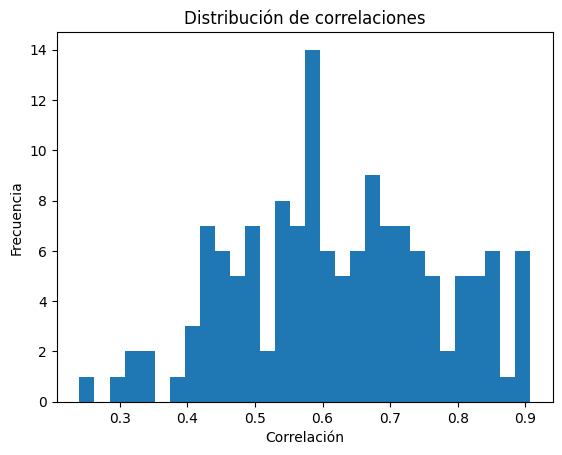

In [15]:
import matplotlib.pyplot as plt

# predicción del modelo (x.hat)
x_hat = model.predict(xtrain)

# correlación columna a columna
corr_matrix = np.corrcoef(x_hat.T, xtrain.T)

# extraer la diagonal (correlación de cada proteína consigo misma)
n_features = xtrain.shape[1]
vcor = np.diag(corr_matrix[:n_features, n_features:])

# histograma
plt.hist(vcor, bins=30)
plt.xlabel("Correlación")
plt.ylabel("Frecuencia")
plt.title("Distribución de correlaciones")
plt.show()

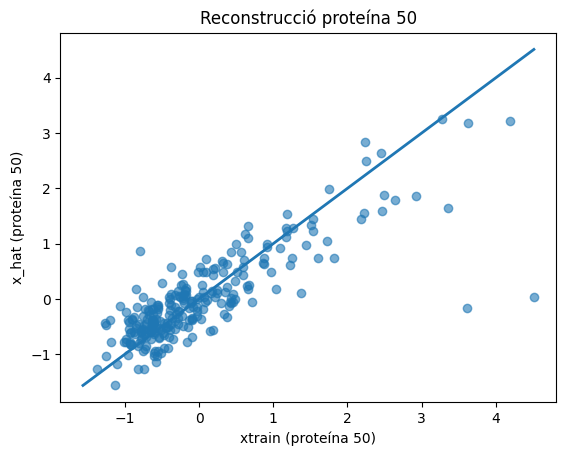

In [16]:
# scatter plot: reconstruido vs original (proteína 50)
plt.scatter(xtrain[:, 49], x_hat[:, 49], alpha=0.6) # alpha es la trasnparencia del punts.

# recta y = x
min_val = min(xtrain[:, 49].min(), x_hat[:, 49].min())
max_val = max(xtrain[:, 49].max(), x_hat[:, 49].max())
plt.plot([min_val, max_val], [min_val, max_val], linewidth=2)

plt.xlabel("xtrain (proteína 50)")
plt.ylabel("x_hat (proteína 50)")
plt.title("Reconstrucció proteína 50")
plt.show()


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


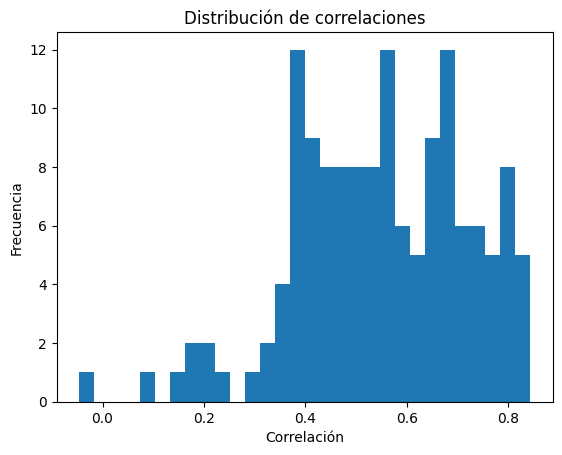

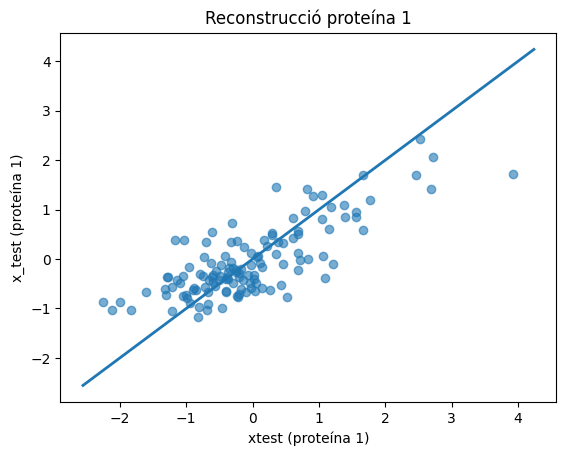

In [17]:
# predicción del modelo (x.hat)
x_hat = model.predict(xtest)

# correlación columna a columna
corr_matrix = np.corrcoef(x_hat.T, xtest.T) # la T es trasposar la matriu, numpy asumeix que les files son les variables

# extraer la diagonal (correlación de cada proteína consigo misma)
n_features = xtest.shape[1]
vcor = np.diag(corr_matrix[:n_features, n_features:])

# histograma
plt.hist(vcor, bins=30)
plt.xlabel("Correlación")
plt.ylabel("Frecuencia")
plt.title("Distribución de correlaciones")
plt.show()

# scatter plot: reconstruido vs original (proteína 50)
plt.scatter(xtest[:, 0], x_hat[:, 0], alpha=0.6) # alpha es la trasnparencia del punts.

# recta y = x
plt.plot(plt.xlim(), plt.xlim(), linewidth=2)

plt.xlabel("xtest (proteína 1)")
plt.ylabel("x_test (proteína 1)")
plt.title("Reconstrucció proteína 1")
plt.show()


# Defining Encoder and Decoder submodels

In [41]:
# capa de entrada encoder
input_enc = keras.Input(shape=(142,))

# capas del encoder
encoded = layers.Dense(50, activation="relu")(input_enc)
output_enc = layers.Dense(20, activation="relu")(encoded)

# modelo encoder
encoder = keras.Model(inputs=input_enc, outputs=output_enc)

# resumen del modelo
encoder.summary()

# capa entrada decoder
input_dec = keras.Input(shape=(20,))

# capas del decoder
decoded = layers.Dense(50, activation="relu")(input_dec)
output_dec = layers.Dense(142, activation="linear")(decoded)

# modelo decoder

decoder= keras.Model(inputs=input_dec, outputs=output_dec)

# resumen del modelo
decoder.summary()



Model: "functional_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_29 (InputLayer)     │ (None, 142)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 50)             │         7,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 20)             │         1,020 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,170 (31.91 KB)

 Trainable params: 8,170 (31.91 KB)

 Non-trainable params: 0 (0.00 B)

Model: "functional_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_30 (InputLayer)     │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 50)             │         1,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 142)            │         7,242 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,292 (32.39 KB)

 Trainable params: 8,292 (32.39 KB)

 Non-trainable params: 0 (0.00 B)

# Defining Autoencoder

In [42]:
aen = keras.Model(inputs=input_enc, outputs=decoder(encoder(input_enc)))
aen.summary()

Model: "functional_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_29 (InputLayer)     │ (None, 142)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_26 (Functional)      │ (None, 20)             │         8,170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_27 (Functional)      │ (None, 142)            │         8,292 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,462 (64.30 KB)

 Trainable params: 16,462 (64.30 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
aen.compile(optimizer="rmsprop", loss="mse")
aen.fit(xtrain, xtrain, epochs=25, batch_size=64, validation_split=0.2)

Epoch 1/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - loss: 1.0969 - val_loss: 0.9663
Epoch 2/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 1.0234 - val_loss: 0.9561
Epoch 3/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 1.0122 - val_loss: 0.9451
Epoch 4/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.9640 - val_loss: 0.9319
Epoch 5/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.9610 - val_loss: 0.9151
Epoch 6/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.9538 - val_loss: 0.8896
Epoch 7/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.9163 - val_loss: 0.8542
Epoch 8/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.8830 - val_loss: 0.8297
Epoch 9/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.8765 - val_loss: 0.8012
Epoch 10/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.8130 - val_loss: 0.7746
Epoch 11/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.8075 - val_loss: 0.7562
Epoch 12/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.7881 - val_loss: 0.7359


In [25]:
#### NO equivalente, porque output_dec no esta conectado a input_dec
aen = keras.Model(input_enc, output_dec)
aen.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 50)        │      1,050 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_6       │ (None, 142)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 142)       │      7,242 │ dense_16[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,292 (32.39 KB)

 Trainable params: 8,292 (32.39 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Generar representaciones codificadas y decodificadas
encoded_expression = encoder.predict(xtrain)
decoded_expression = decoder.predict(encoded_expression)

# Escalar por fila (equivalente a scale="row" en R)
scaler = StandardScaler(with_mean=True, with_std=True)
encoded_scaled = scaler.fit_transform(encoded_expression.T).T

# Paleta de colores similar a brewer.pal(8, "Blues") con 15 niveles
col_main = sns.color_palette("Blues", 15)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


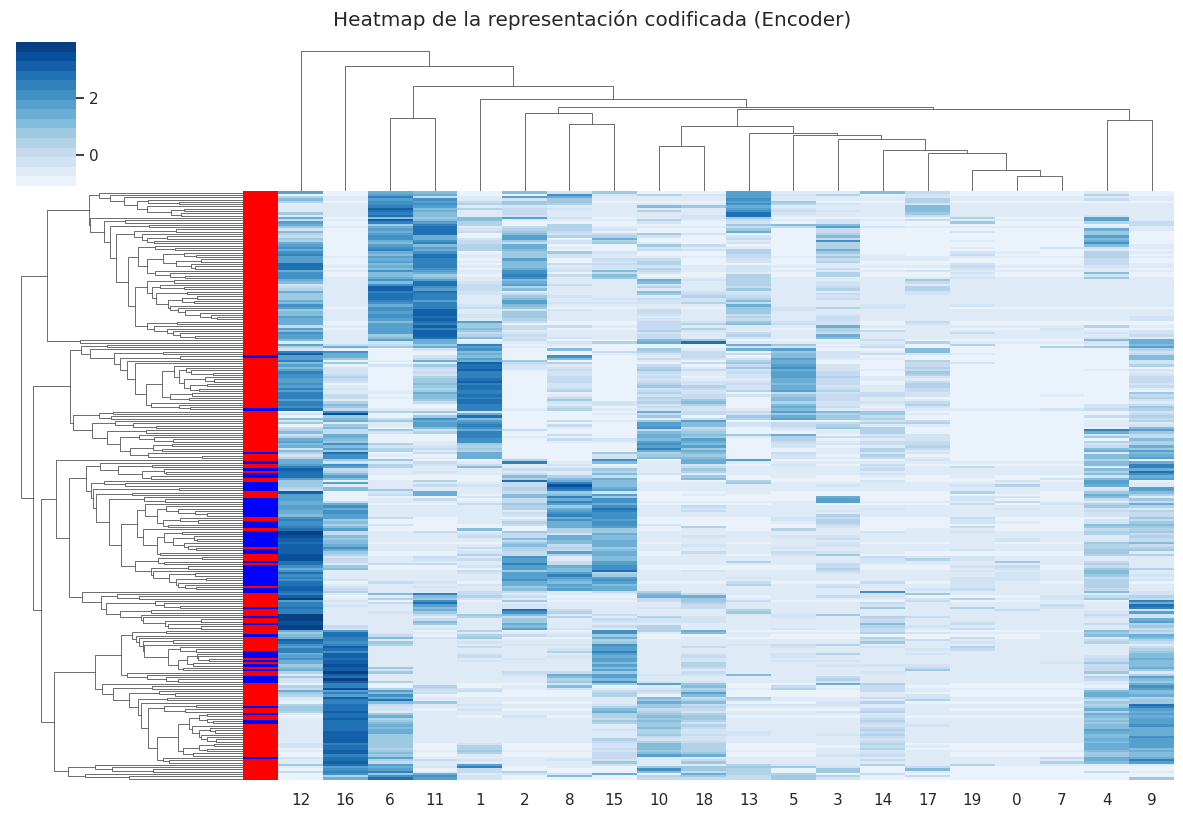

In [32]:

# Colores de filas según etiquetas ----
# Suponiendo ylabels = 0/1 (0=Negativo, 1=Positivo)
row_colors = np.array(['red' if y == 1 else 'blue' for y in ylabels])

sns.set(style="white")
g = sns.clustermap(
    encoded_scaled,           # datos normalizados
    row_colors=row_colors,    # colores de filas
    col_cluster=True,
    cmap=col_main,             # paleta azul
    yticklabels=False,
    xticklabels=True,
    figsize=(12, 8)
)

plt.suptitle("Heatmap de la representación codificada (Encoder)", y=1.02)
plt.show()


# Stacked autoencoder

In [79]:
#AE1
input_enc1 = keras.Input(shape=(142,))
output_enc1 = layers.Dense(50, activation="relu")(input_enc1)
encoder1 = keras.Model(inputs=input_enc1, outputs=output_enc1)
encoder1.summary()
input_dec1 = keras.Input(shape=(50,))
output_dec1 = layers.Dense(142, activation="linear")(input_dec1)
decoder1 = keras.Model(inputs=input_dec1, outputs=output_dec1)
decoder1.summary()

aen_input1 = keras.Input(shape=(142,))
aen_output1 = decoder1(encoder1(aen_input1))
sae1 = keras.Model(inputs=aen_input1, outputs=aen_output1)
sae1.summary()

sae1.compile(optimizer="rmsprop", loss="mse")
sae1.fit(xtrain, xtrain, epochs=25, batch_size=64, validation_split=0.2)
encoded_expression1 = encoder1.predict(xtrain)


#AE2
input_enc2 = keras.Input(shape=(50,))
output_enc2 = layers.Dense(20, activation="relu")(input_enc2)
encoder2 = keras.Model(inputs=input_enc2, outputs=output_enc2)
encoder2.summary()
input_dec2 = keras.Input(shape=(20,))
output_dec2 = layers.Dense(50, activation="linear")(input_dec2)
decoder2 = keras.Model(inputs=input_dec2, outputs=output_dec2)
decoder2.summary()

aen_input2 = keras.Input(shape=(50,))
aen_output2 = decoder2(encoder2(aen_input2))
sae2 = keras.Model(inputs=aen_input2, outputs=aen_output2)
sae2.summary()

sae2.compile(optimizer="rmsprop", loss="mse")
sae2.fit(encoded_expression1, encoded_expression1, epochs=25, batch_size=64, validation_split=0.2)
encoded_expression2 = encoder2.predict(encoded_expression1)

#AE3
input_enc3 = keras.Input(shape=(20,))
output_enc3 = layers.Dense(10, activation="relu")(input_enc3)
encoder3 = keras.Model(inputs=input_enc3, outputs=output_enc3)
encoder3.summary()
input_dec3 = keras.Input(shape=(10,))
output_dec3 = layers.Dense(20, activation="linear")(input_dec3)
decoder3 = keras.Model(inputs=input_dec3, outputs=output_dec3)
decoder3.summary()

aen_input3 = keras.Input(shape=(20,))
aen_output3 = decoder3(encoder3(aen_input3))
sae3 = keras.Model(inputs=aen_input3, outputs=aen_output3)
sae3.summary()

sae3.compile(optimizer="rmsprop", loss="mse")
sae3.fit(encoded_expression2, encoded_expression2, epochs=25, batch_size=64, validation_split=0.2)
encoded_expression3 = encoder3.predict(encoded_expression2)



Model: "functional_45"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_51 (InputLayer)     │ (None, 142)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 50)             │         7,150 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,150 (27.93 KB)

 Trainable params: 7,150 (27.93 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_59 (InputLayer)     │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_51 (Functional)      │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_52 (Functional)      │ (None, 20)             │           220 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 430 (1.68 KB)

 Trainable params: 430 (1.68 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - loss: 0.8145 - val_loss: 0.7442
Epoch 2/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.7491 - val_loss: 0.7179
Epoch 3/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.6684 - val_loss: 0.6970
Epoch 4/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.6710 - val_loss: 0.6787
Epoch 5/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.6390 - val_loss: 0.6611
Epoch 6/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.6418 - val_loss: 0.6462
Epoch 7/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.6509 - val_loss: 0.6332
Epoch 8/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.6382 - val_loss: 0.6197
Epoch 9/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.6430 - val_loss: 0.6036
Epoch 10/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.6219 - val_loss: 0.5927
Epoch 11/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.6122 - val_loss: 0.5814
Epoch 12/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.5939 - val_loss: 0.5681


In [80]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
# Final Model
sae_input = keras.Input(shape=(142,))
sae_output = encoder3(encoder2(encoder1(sae_input)))
sae_output = layers.Dense(5,activation="relu")(sae_output)
sae_output = layers.Dense(1,activation="sigmoid")(sae_output)
sae = keras.Model(inputs=sae_input, outputs=sae_output)
sae.summary()

Model: "functional_54"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_60 (InputLayer)     │ (None, 142)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_45 (Functional)      │ (None, 50)             │         7,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_48 (Functional)      │ (None, 20)             │         1,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_51 (Functional)      │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,441 (32.97 KB)

 Trainable params: 8,441 (32.97 KB)

 Non-trainable params: 0 (0.00 B)

In [82]:
for layer in sae.layers[0:3]:
    layer.trainable = False
sae.summary()
for layer in sae.layers:
    print(layer.name, layer.trainable)
    # se coongelan los encoders, participan pero no se ajusta.


Model: "functional_54"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_60 (InputLayer)     │ (None, 142)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_45 (Functional)      │ (None, 50)             │         7,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_48 (Functional)      │ (None, 20)             │         1,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_51 (Functional)      │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,441 (32.97 KB)

 Trainable params: 271 (1.06 KB)

 Non-trainable params: 8,170 (31.91 KB)

input_layer_60 False
functional_45 False
functional_48 False
functional_51 True
dense_63 True
dense_64 True


In [86]:
sae.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])
history = sae.fit(xtrain, ylabels,epochs=30,batch_size=64,validation_split=0.2)

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.7669 - loss: 0.4549 - val_accuracy: 0.7647 - val_loss: 0.4194
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7534 - loss: 0.4575 - val_accuracy: 0.7647 - val_loss: 0.4153
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7560 - loss: 0.4440 - val_accuracy: 0.7647 - val_loss: 0.4120
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7633 - loss: 0.4505 - val_accuracy: 0.7647 - val_loss: 0.4079
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7576 - loss: 0.4317 - val_accuracy: 0.7647 - val_loss: 0.4040
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7612 - loss: 0.4438 - val_accuracy: 0.7647 - val_loss: 0.4011
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7732 - loss: 0.4213 - val_accuracy: 0.7647 - val_loss: 0.3999
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7576 - loss: 0.4257 - val_accuracy: 0.7647 - val_loss: 0.3969


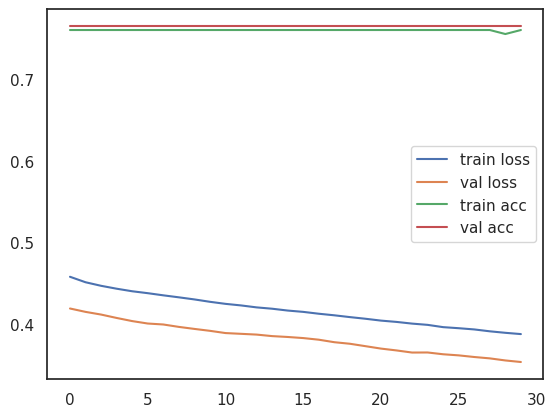

In [87]:
plt.figure()
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()


In [99]:
loss, acc = sae.evaluate(xtest, ytestlabels, verbose=0)
print("loss:", loss)
print("accuracy:", acc)
# Predicciones (probabilidades)
yhat = sae.predict(xtest)

# Clases con umbral 0.5
yhat_class = np.where(yhat < 0.51, 0, 1).ravel()

# Tabla de contingencia (equivalente a table())
table = pd.crosstab(
    yhat_class,
    ytestlabels,
    rownames=["yhatclass"],
    colnames=["ytestlabels"]
)

print(table)
from sklearn.metrics import confusion_matrix, classification_report

# Asegúrate de que yhat_class y ytestlabels sean vectores 1D
yhat_class = yhat_class.ravel()  # si aún tiene shape (n,1)
ytestlabels = np.array(ytestlabels).ravel()

# Matriz de confusión
cm = confusion_matrix(ytestlabels, yhat_class)
print("Confusion matrix:\n", cm)

# Métricas completas (accuracy, precision, recall, f1)
print("\nClassification report:")
print(classification_report(ytestlabels, yhat_class))
# se ha predicho todo como positivo



loss: 0.46047383546829224
accuracy: 0.7265625
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
ytestlabels   0   1
yhatclass          
0             2   1
1            33  92
Confusion matrix:
 [[ 2 33]
 [ 1 92]]

Classification report:
              precision    recall  f1-score   support

           0       0.67      0.06      0.11        35
           1       0.74      0.99      0.84        93

    accuracy                           0.73       128
   macro avg       0.70      0.52      0.47       128
weighted avg       0.72      0.73      0.64       128



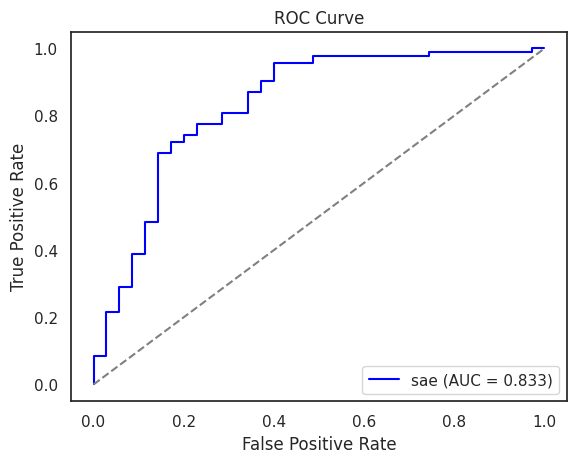

In [95]:
from sklearn.metrics import roc_curve, auc
# yhat debe ser PROBABILIDAD, no clase
yhat_prob = yhat.ravel()   # equivalente a as.numeric(yhat)

# ROC
fpr, tpr, thresholds = roc_curve(ytestlabels, yhat_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color="blue", label=f"sae (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey")  # diagonal random
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()
